# **A Comparative Analysis of Deep Learning and Stacking-Based Models for Brain Tumour Detection Using MRI Images**

# **#  Mounting Google Drive for Dataset Access**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# **Extract Dataset from ZIP File**

In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/Thesis 2026_MY/ED (Brain Tumor)/archive (3).zip'
extracted_folder_path = '/mnt/data/extracted_files/'
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_folder_path)
extracted_files = os.listdir(extracted_folder_path)
extracted_files

['Testing', 'Training']

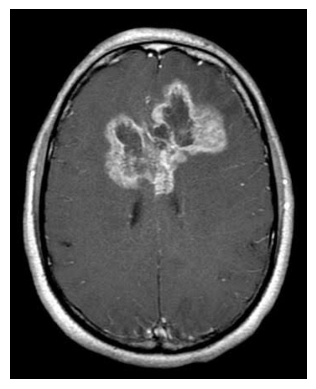

In [ ]:
testing_folder_path = '/mnt/data/extracted_files/Testing'
sample_image_path_corrected = os.path.join(testing_folder_path, 'glioma', 'Te-gl_1.jpg')
sample_image = Image.open(sample_image_path_corrected)
plt.imshow(sample_image)
plt.axis('off')
plt.show()

# **Loading and Preprocessing Brain Tumour MRI Images**

In [ ]:
import os
from PIL import Image
import numpy as np

# Define the categories and their corresponding folder paths
categories = ['glioma', 'meningioma', 'notumor', 'pituitary']
data_dir = '/mnt/data/extracted_files'
def load_data_from_folder(folder_path, categories, image_size=(64, 64)):
    images = []
    labels = []

    for category in categories:
        category_folder = os.path.join(folder_path, category)
        for image_name in os.listdir(category_folder):
            image_path = os.path.join(category_folder, image_name)
            image = Image.open(image_path)
            image = image.convert('RGB')
            image = image.resize(image_size)
            image = np.array(image)
            images.append(image)
            labels.append(category)

    return np.array(images), np.array(labels)

# Load training and testing data
training_images, training_labels = load_data_from_folder(os.path.join(data_dir, 'Training'), categories)
testing_images, testing_labels = load_data_from_folder(os.path.join(data_dir, 'Testing'), categories)

# Output shapes of the data
print(f"Training data shape: {training_images.shape}")
print(f"Testing data shape: {testing_images.shape}")

Training data shape: (5600, 64, 64, 3)
Testing data shape: (1600, 64, 64, 3)


# **Check Class Distribution of Training and Testing Data**

In [ ]:
import pandas as pd
def check_data_balance(labels):
    label_counts = pd.Series(labels).value_counts()
    return label_counts

# Check balance for both training and testing labels
training_balance = check_data_balance(training_labels)
testing_balance = check_data_balance(testing_labels)
training_balance, testing_balance

(glioma        1400
 meningioma    1400
 notumor       1400
 pituitary     1400
 Name: count, dtype: int64,
 glioma        400
 meningioma    400
 notumor       400
 pituitary     400
 Name: count, dtype: int64)

# **Exploratory Data Analysis: Graphical Visualization of Class Distribution**

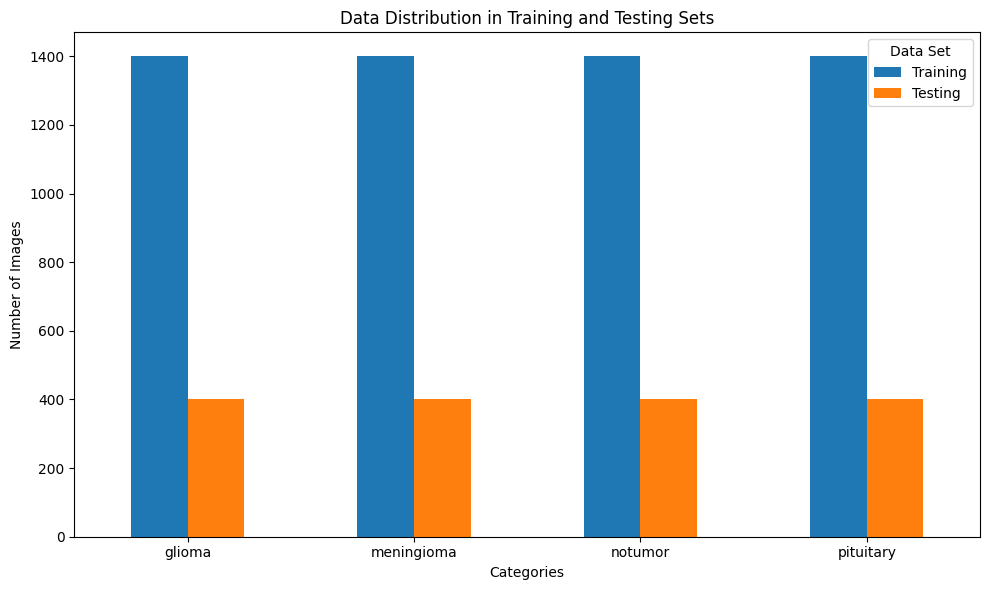

In [ ]:
import matplotlib.pyplot as plt
data_balance = pd.DataFrame({
    'Training': training_balance,
    'Testing': testing_balance
})

# Plot the data balance
data_balance.plot(kind='bar', figsize=(10, 6))
plt.title('Data Distribution in Training and Testing Sets')
plt.xlabel('Categories')
plt.ylabel('Number of Images')
plt.xticks(rotation=0)
plt.legend(title='Data Set')
plt.tight_layout()
plt.show()

# **End-to-End Deep Learning Input Pipeline for Multi-Class Brain Tumour Classification**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

data_dir = "/mnt/data/extracted_files"
train_dir = os.path.join(data_dir, "Training")
test_dir  = os.path.join(data_dir, "Testing")

# Hyperparams
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42
VAL_SPLIT = 0.10
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset="training"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset="validation"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class names:", train_ds.class_names)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.10),
    layers.GaussianNoise(0.02),
], name="data_augmentation")

# 3) Normalization layer
normalizer = layers.Rescaling(1./255)

AUTOTUNE = tf.data.AUTOTUNE

# 4) Apply augmentation ONLY on training data
train_ds = train_ds.map(
    lambda x, y: (normalizer(data_augmentation(x, training=True)), y),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalizer(x), y),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (normalizer(x), y),
    num_parallel_calls=AUTOTUNE
)

# 5) Performance
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

print("Augmented train_ds ready ")

Found 5600 files belonging to 4 classes.
Using 5040 files for training.
Found 5600 files belonging to 4 classes.
Using 560 files for validation.
Found 1600 files belonging to 4 classes.
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Augmented train_ds ready 


# **Visual Inspection of Data Augmentation Effects**

Found 5600 files belonging to 4 classes.
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


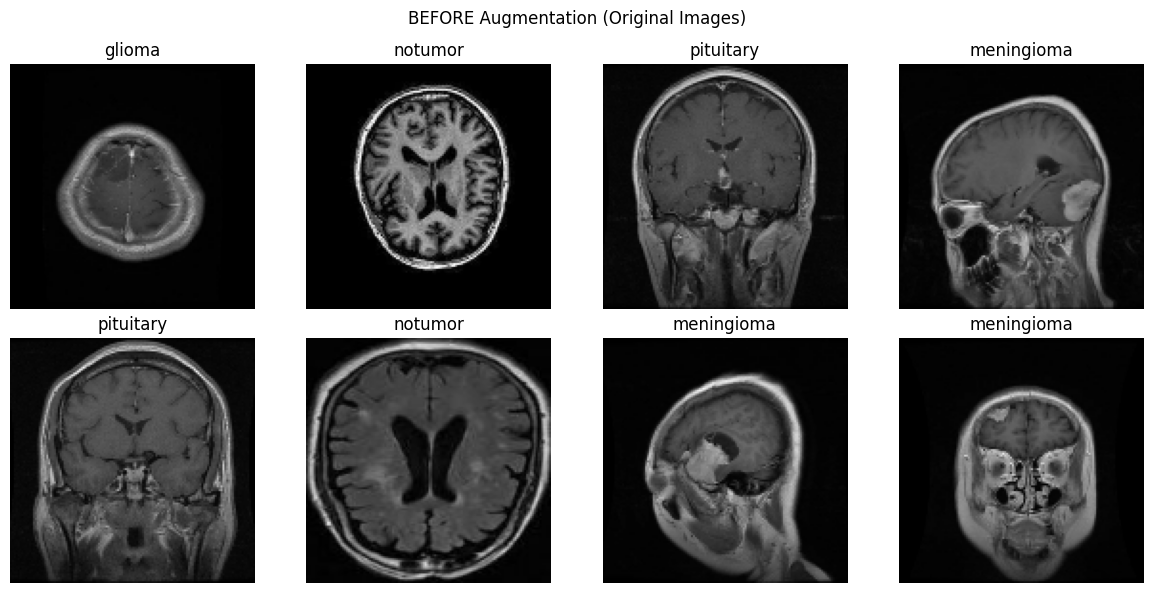

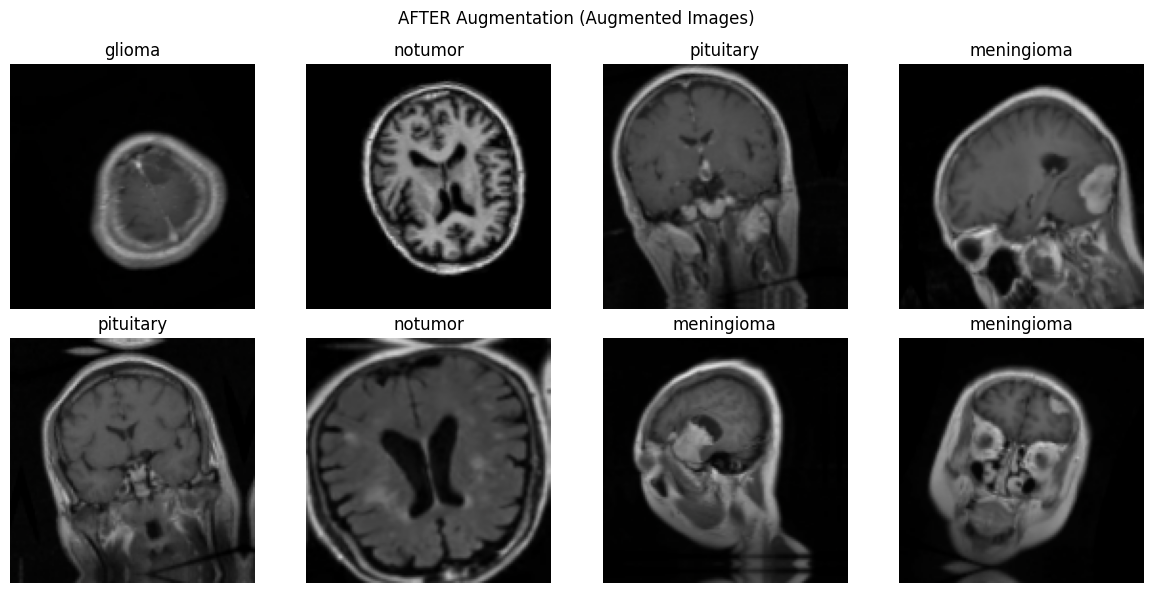

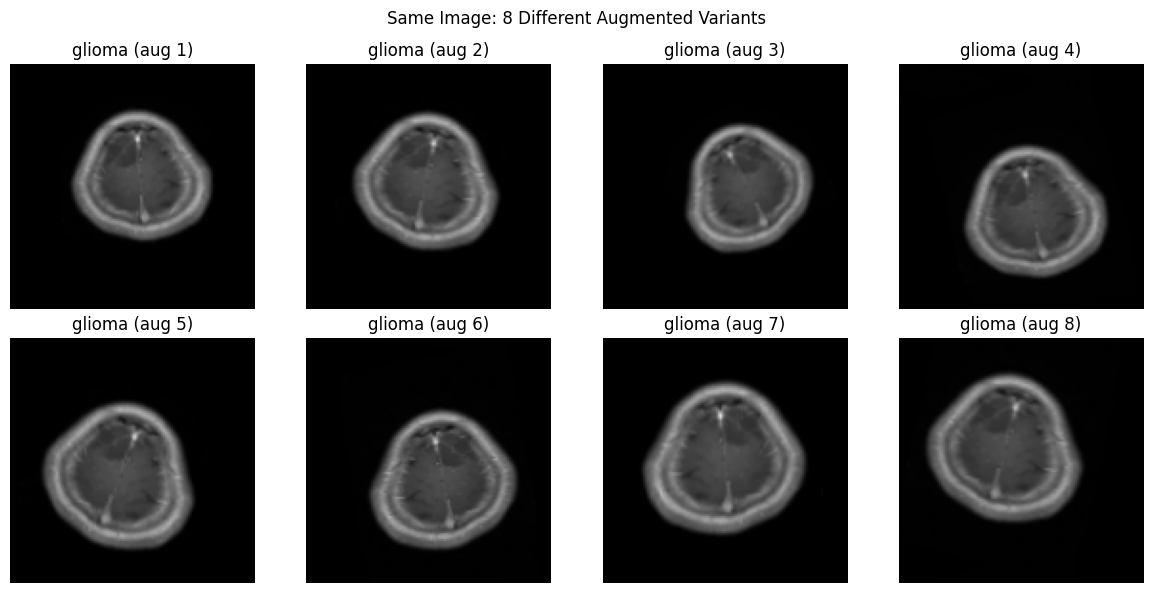

In [ ]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
data_dir = "/mnt/data/extracted_files"
train_dir = os.path.join(data_dir, "Training")

# Hyperparams
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

# Load a small batch (unaugmented)
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

class_names = raw_train_ds.class_names
print("Class names:", class_names)

# Define augmentation (Option A)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.10),
    layers.GaussianNoise(0.02),
], name="data_augmentation")

# Get one batch
images, labels = next(iter(raw_train_ds))
n_show = 8

# Plot BEFORE augmentation
plt.figure(figsize=(12, 6))
for i in range(n_show):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(tf.cast(images[i], tf.uint8))
    plt.title(class_names[int(labels[i])])
    plt.axis("off")
plt.suptitle("BEFORE Augmentation (Original Images)")
plt.tight_layout()
plt.show()

# Apply augmentation to the same images
aug_images = data_augmentation(images[:n_show], training=True)

# Plot AFTER augmentation
plt.figure(figsize=(12, 6))
for i in range(n_show):
    ax = plt.subplot(2, 4, i + 1)
    # Clip values to valid range for display
    img = tf.clip_by_value(aug_images[i], 0, 255)
    plt.imshow(tf.cast(img, tf.uint8))
    plt.title(class_names[int(labels[i])])
    plt.axis("off")
plt.suptitle("AFTER Augmentation (Augmented Images)")
plt.tight_layout()
plt.show()

# Bonus: show multiple augmented variants of ONE image to visualize randomness
img0 = images[0:1]  # shape (1, H, W, 3)
label0 = class_names[int(labels[0])]

plt.figure(figsize=(12, 6))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    aug = data_augmentation(img0, training=True)[0]
    aug = tf.clip_by_value(aug, 0, 255)
    plt.imshow(tf.cast(aug, tf.uint8))
    plt.title(f"{label0} (aug {i+1})")
    plt.axis("off")
plt.suptitle("Same Image: 8 Different Augmented Variants")
plt.tight_layout()
plt.show()

# **Dataset Splitting and Batching: Train, Validation, and Test Sets Overviewv**

In [ ]:
import tensorflow as tf
import os

data_dir = "/mnt/data/extracted_files"
train_dir = os.path.join(data_dir, "Training")
test_dir  = os.path.join(data_dir, "Testing")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42
VAL_SPLIT = 0.10

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())
print("Classes:", train_ds.class_names)

Found 5600 files belonging to 4 classes.
Using 5040 files for training.
Found 5600 files belonging to 4 classes.
Using 560 files for validation.
Found 1600 files belonging to 4 classes.
Train batches: 158
Val batches: 18
Test batches: 50
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
import os, glob, random, shutil, hashlib
import pandas as pd
data_dir = "/mnt/data/extracted_files"
old_train_dir = os.path.join(data_dir, "Training")
old_test_dir  = os.path.join(data_dir, "Testing")

out_root = "/mnt/data/split_70_10_20"
splits = {"Train": 0.70, "Validation": 0.10, "Test": 0.20}

categories = ["glioma", "meningioma", "notumor", "pituitary"]
SEED = 42
random.seed(SEED)

def safe_copy(src, dst_dir):
    os.makedirs(dst_dir, exist_ok=True)
    base = os.path.basename(src)
    name, ext = os.path.splitext(base)
    dst = os.path.join(dst_dir, base)
    if not os.path.exists(dst):
        shutil.copy2(src, dst)
        return dst

    h = hashlib.md5(src.encode("utf-8")).hexdigest()[:8]
    dst = os.path.join(dst_dir, f"{name}_{h}{ext}")
    shutil.copy2(src, dst)
    return dst

all_by_class = {}
for c in categories:
    paths = []
    paths += glob.glob(os.path.join(old_train_dir, c, "*"))
    paths += glob.glob(os.path.join(old_test_dir,  c, "*"))
    paths = [p for p in paths if os.path.isfile(p)]
    all_by_class[c] = paths

total_images = sum(len(v) for v in all_by_class.values())
print("Total images found (Training+Testing):", total_images)
for c in categories:
    print(f"{c}: {len(all_by_class[c])}")

for split_name in splits.keys():
    for c in categories:
        os.makedirs(os.path.join(out_root, split_name, c), exist_ok=True)

records = []

split_counts = {s: {c: 0 for c in categories} for s in splits.keys()}

for c in categories:
    paths = all_by_class[c][:]
    random.shuffle(paths)
    n = len(paths)

    n_test = int(round(splits["Test"] * n))
    n_val  = int(round(splits["Validation"] * n))
    n_train = n - n_test - n_val  # remaining

    train_paths = paths[:n_train]
    val_paths   = paths[n_train:n_train+n_val]
    test_paths  = paths[n_train+n_val:]

    # Copy
    for p in train_paths:
        dst = safe_copy(p, os.path.join(out_root, "Train", c))
        records.append({"split": "Train", "class": c, "src": p, "dst": dst})
        split_counts["Train"][c] += 1

    for p in val_paths:
        dst = safe_copy(p, os.path.join(out_root, "Validation", c))
        records.append({"split": "Validation", "class": c, "src": p, "dst": dst})
        split_counts["Validation"][c] += 1

    for p in test_paths:
        dst = safe_copy(p, os.path.join(out_root, "Test", c))
        records.append({"split": "Test", "class": c, "src": p, "dst": dst})
        split_counts["Test"][c] += 1

summary_df = pd.DataFrame(split_counts).T[categories]
summary_df.loc["TOTAL"] = summary_df.sum(axis=0)
summary_df["ALL_CLASSES_TOTAL"] = summary_df.sum(axis=1)

print("\n Split completed. New dataset folder:", out_root)
print("\nPer-split counts (per class):")
display(summary_df)
mapping_df = pd.DataFrame(records)
csv_path = os.path.join(out_root, "split_mapping_70_10_20.csv")
mapping_df.to_csv(csv_path, index=False)

print("\nSaved mapping CSV:", csv_path)
print("Output folders:", os.listdir(out_root))

Total images found (Training+Testing): 7200
glioma: 1800
meningioma: 1800
notumor: 1800
pituitary: 1800

 Split completed. New dataset folder: /mnt/data/split_70_10_20

Per-split counts (per class):


,glioma,meningioma,notumor,pituitary,ALL_CLASSES_TOTAL
Train,1260,1260,1260,1260,5040
Validation,180,180,180,180,720
Test,360,360,360,360,1440
TOTAL,1800,1800,1800,1800,7200



Saved mapping CSV: /mnt/data/split_70_10_20/split_mapping_70_10_20.csv
Output folders: ['Test', 'Validation', 'split_mapping_70_10_20.csv', 'Train']


# **Randomized Train, Validation, and Test Split with Class-Wise Distribution Analysis**

Total images: 7200
Overall split counts: {'train': 5040, 'val': 720, 'test': 1440}


,Train(70%),Val(10%),Test(20%)
glioma,1260,180,360
meningioma,1260,180,360
notumor,1260,180,360
pituitary,1260,180,360


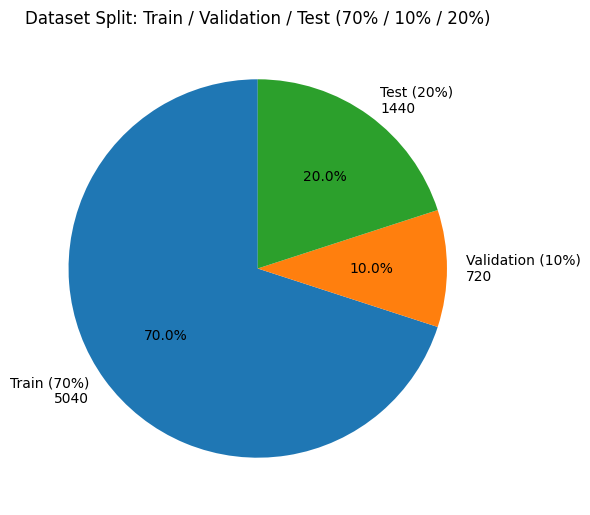

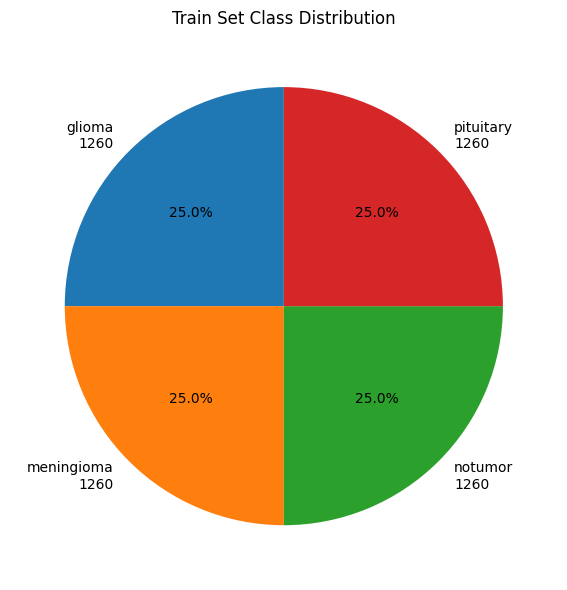

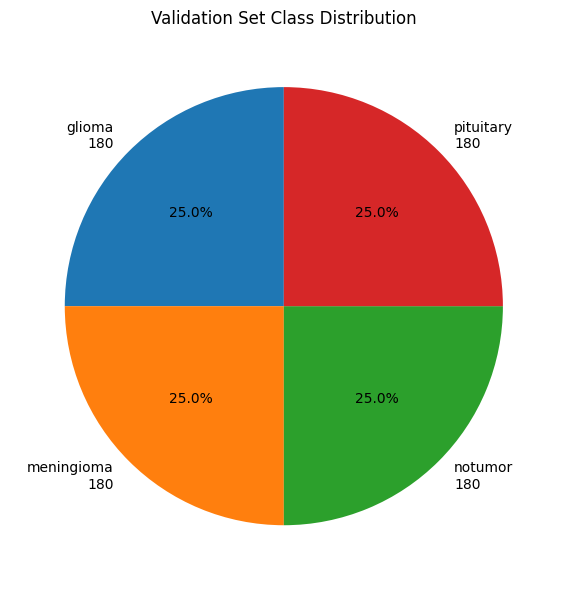

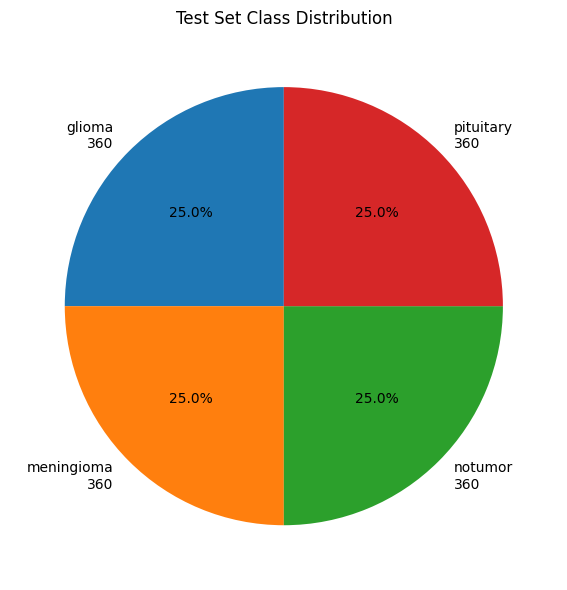

In [ ]:
import os, glob, random
import pandas as pd
import matplotlib.pyplot as plt
data_dir = "/mnt/data/extracted_files"
old_train_dir = os.path.join(data_dir, "Training")
old_test_dir  = os.path.join(data_dir, "Testing")
categories = ["glioma", "meningioma", "notumor", "pituitary"]
SEED = 42

def collect_paths(root_dir):
    paths, labels = [], []
    for c in categories:
        cdir = os.path.join(root_dir, c)
        for p in glob.glob(os.path.join(cdir, "*")):
            paths.append(p)
            labels.append(c)
    return paths, labels

train_paths, train_labels = collect_paths(old_train_dir)
test_paths,  test_labels  = collect_paths(old_test_dir)

all_paths  = train_paths + test_paths
all_labels = train_labels + test_labels
random.seed(SEED)

splits = {"train": [], "val": [], "test": []}
split_labels = {"train": [], "val": [], "test": []}

for c in categories:
    class_paths = [p for p, y in zip(all_paths, all_labels) if y == c]
    random.shuffle(class_paths)
    n = len(class_paths)
    n_test = int(round(0.20 * n))
    n_val  = int(round(0.10 * n))
    n_train = n - n_test - n_val

    splits["train"].extend(class_paths[:n_train])
    split_labels["train"].extend([c]*n_train)

    splits["val"].extend(class_paths[n_train:n_train+n_val])
    split_labels["val"].extend([c]*n_val)

    splits["test"].extend(class_paths[n_train+n_val:])
    split_labels["test"].extend([c]*(n - n_train - n_val))

overall_counts = {k: len(v) for k, v in splits.items()}
per_class_counts = pd.DataFrame({
    "Train(70%)": pd.Series(split_labels["train"]).value_counts(),
    "Val(10%)":   pd.Series(split_labels["val"]).value_counts(),
    "Test(20%)":  pd.Series(split_labels["test"]).value_counts(),
}).fillna(0).astype(int).reindex(categories)

print("Total images:", len(all_paths))
print("Overall split counts:", overall_counts)
display(per_class_counts)
plt.figure(figsize=(6,6))
plt.pie(
    [overall_counts["train"], overall_counts["val"], overall_counts["test"]],
    labels=[f"Train (70%)\n{overall_counts['train']}", f"Validation (10%)\n{overall_counts['val']}", f"Test (20%)\n{overall_counts['test']}"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Dataset Split: Train / Validation / Test (70% / 10% / 20%)")
plt.tight_layout()
plt.show()

for split_name, title in [("train","Train Set Class Distribution"), ("val","Validation Set Class Distribution"), ("test","Test Set Class Distribution")]:
    counts = pd.Series(split_labels[split_name]).value_counts().reindex(categories).fillna(0).astype(int)
    plt.figure(figsize=(6,6))
    plt.pie(counts.values, labels=[f"{k}\n{v}" for k,v in counts.items()], autopct="%1.1f%%", startangle=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# **CNN Model Construction, Hyperparameter Optimization, and Test Set Evaluation**

Found 5040 files belonging to 4 classes.
Found 720 files belonging to 4 classes.
Found 1440 files belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.4825 - loss: 1.1310 - val_accuracy: 0.7681 - val_loss: 0.5937
Epoch 2/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.7083 - loss: 0.7087 - val_accuracy: 0.8000 - val_loss: 0.5057
Epoch 3/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.7688 - loss: 0.5639 - val_accuracy: 0.8028 - val_loss: 0.4798
Epoch 4/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.7946 - loss: 0.5069 - val_accuracy: 0.8625 - val_loss: 0.3571
Epoch 5/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8186 - loss: 0.4311 - val_accuracy: 0.8847 - val_loss: 0.3060
Epoch 6/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.8355 - loss: 0.3918 - val_accuracy: 0.8903 - val_loss: 0.2846
Epoch 7/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8611 - loss: 0.3296 - val_accuracy: 0.8931 - val_loss: 0.2964
Epoch 8/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8676 - loss: 0.3031 - val_acc

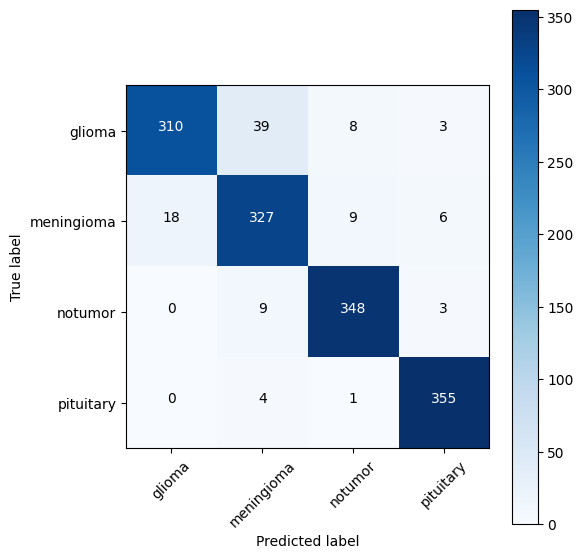


Classification Report (CNN):
              precision    recall  f1-score   support

      glioma       0.95      0.86      0.90       360
  meningioma       0.86      0.91      0.88       360
     notumor       0.95      0.97      0.96       360
   pituitary       0.97      0.99      0.98       360

    accuracy                           0.93      1440
   macro avg       0.93      0.93      0.93      1440
weighted avg       0.93      0.93      0.93      1440



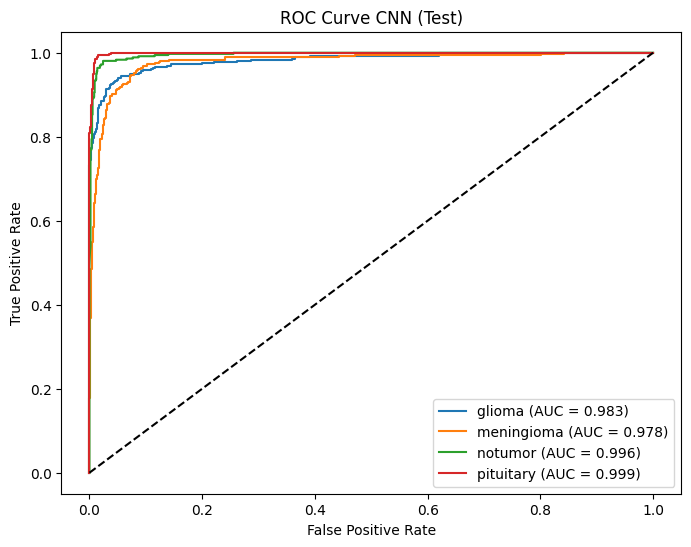

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import itertools

data_dir = "/mnt/data/split_70_10_20"
train_dir = os.path.join(data_dir, "Train")
val_dir   = os.path.join(data_dir, "Validation")
test_dir  = os.path.join(data_dir, "Test")

IMG_SIZE = (128,128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED)
val_ds = tf.keras.utils.image_dataset_from_directory(val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED)
test_ds = tf.keras.utils.image_dataset_from_directory(test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_ds.class_names
num_classes = len(class_names)

normalizer = keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x,y: (normalizer(x),y))
val_ds   = val_ds.map(lambda x,y: (normalizer(x),y))
test_ds  = test_ds.map(lambda x,y: (normalizer(x),y))

learning_rates = [1e-3, 5e-4]
dropouts = [0.3, 0.5]
best_val_acc = 0
best_params = {}

for lr in learning_rates:
    for dr in dropouts:
        model = keras.Sequential([
            keras.layers.Conv2D(32,3,activation='relu',input_shape=(128,128,3)),
            keras.layers.MaxPooling2D(),
            keras.layers.Conv2D(64,3,activation='relu'),
            keras.layers.MaxPooling2D(),
            keras.layers.Conv2D(128,3,activation='relu'),
            keras.layers.MaxPooling2D(),
            keras.layers.Flatten(),
            keras.layers.Dense(128,activation='relu'),
            keras.layers.Dropout(dr),
            keras.layers.Dense(num_classes,activation='softmax')
        ])
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        history = model.fit(train_ds, validation_data=val_ds, epochs=5, verbose=0)
        val_acc = max(history.history['val_accuracy'])
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_params = {"lr": lr, "dropout": dr}

model = keras.Sequential([
    keras.layers.Conv2D(24,3,activation='relu',input_shape=(128,128,3)),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(48,3,activation='relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(96,3,activation='relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dropout(0.6),
    keras.layers.Dense(num_classes,activation='softmax')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=best_params["lr"]), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_ds, validation_data=val_ds, epochs=15)

test_loss, test_acc = model.evaluate(test_ds)
print("\nTest Accuracy (CNN):", test_acc)

y_true = np.concatenate([y for x,y in test_ds], axis=0)
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix CNN(Test):\n", cm)
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j,i,cm[i,j],horizontalalignment="center", color="white" if cm[i,j] > cm.max()/2 else "black")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

print("\nClassification Report (CNN):")
print(classification_report(y_true, y_pred, target_names=class_names))

y_true_bin = label_binarize(y_true, classes=range(num_classes))
plt.figure(figsize=(8,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_prob[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve CNN (Test)")
plt.legend()
plt.show()

# **Model Inference on Single MRI Images: Prediction, Confidence, and Visualization**

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
IMG_SIZE = (128, 128)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

def predict(img_path):
    # Load image
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    preds = model.predict(img_array)[0]

    # Plot image + probabilities
    plt.figure(figsize=(6,8))

    # Show image
    plt.subplot(2,1,1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input MRI Image")

    # Show probabilities
    plt.subplot(2,1,2)
    bars = plt.barh(class_names, preds)
    plt.xlabel("Probability")
    plt.xlim(0,1)

    # Show probability values
    for i, v in enumerate(preds):
        plt.text(v + 0.02, i, f"{v:.2f}")

    plt.tight_layout()
    plt.show()

    # Print predicted class
    predicted_class = class_names[np.argmax(preds)]
    print("Predicted Class:", predicted_class)
    print("Confidence:", round(np.max(preds)*100,2), "%")

In [ ]:
train_ds = train_ds.map(lambda x,y: (normalizer(x),y))

# **Saving the Trained CNN Model for Future Inference**

In [ ]:
model.save('CNN_model.h5')

# **Downloading the Trained CNN Model**

In [ ]:
from google.colab import files
files.download('/content/CNN_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Loading a Pre-Trained CNN Model from Google Drive**

In [ ]:
from tensorflow.keras.models import load_model
model_path = '/content/drive/MyDrive/Thesis 2026_MY/ED (Brain Tumor)/your_model.h5'
model = load_model(model_path)

# **# Single-Image Prediction Using Pre-Trained CNN**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step


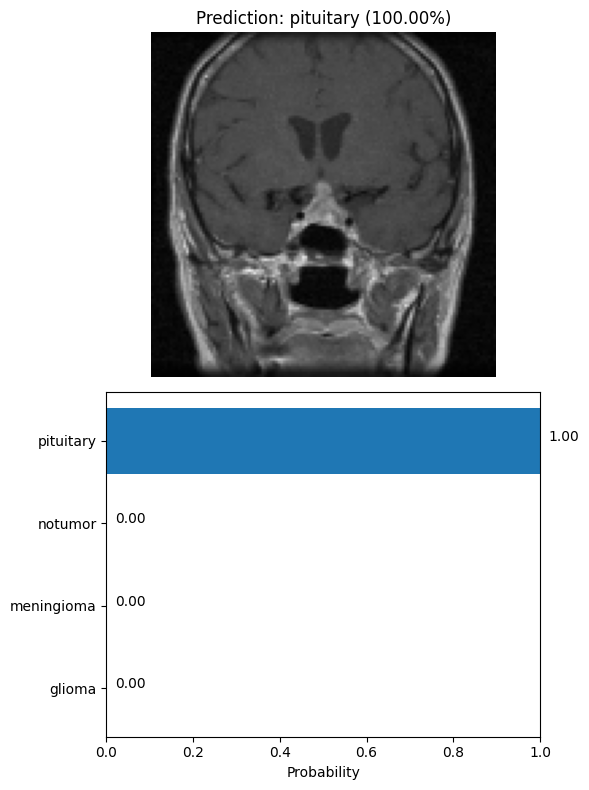

Predicted Class: pituitary
Confidence: 100.0 %


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
model_path = '/content/your_model.h5'
model = tf.keras.models.load_model(model_path)
img_path = ('/mnt/data/extracted_files/Training/pituitary/Tr-pi_160.jpg')
IMG_SIZE = (128, 128)
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)
preds = model.predict(img_array)[0]
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
plt.figure(figsize=(6,8))

plt.subplot(2,1,1)
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {class_names[np.argmax(preds)]} ({np.max(preds)*100:.2f}%)")
plt.subplot(2,1,2)
bars = plt.barh(class_names, preds)
plt.xlim(0, 1)
plt.xlabel("Probability")
for i, v in enumerate(preds):
    plt.text(v + 0.02, i, f"{v:.2f}")
plt.tight_layout()
plt.show()
print("Predicted Class:", class_names[np.argmax(preds)])
print("Confidence:", round(np.max(preds)*100, 2), "%")

# **# Uploading Local Files into Device**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Te-pi_1.jpg to Te-pi_1.jpg


# **Predicting Brain Tumour Class for Uploaded MRI Images**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


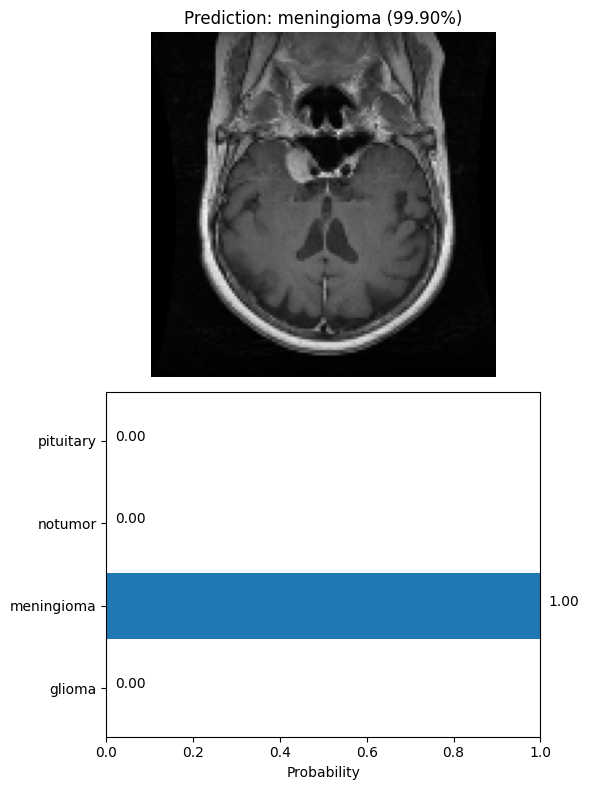

Predicted Class: meningioma
Confidence: 99.9 %


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]
IMG_SIZE = (128, 128)
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)
preds = model.predict(img_array)[0]
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
plt.figure(figsize=(6,8))
plt.subplot(2,1,1)
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {class_names[np.argmax(preds)]} ({np.max(preds)*100:.2f}%)")
plt.subplot(2,1,2)
bars = plt.barh(class_names, preds)
plt.xlim(0, 1)
plt.xlabel("Probability")
for i, v in enumerate(preds):
    plt.text(v + 0.02, i, f"{v:.2f}")
plt.tight_layout()
plt.show()
print("Predicted Class:", class_names[np.argmax(preds)])
print("Confidence:", round(np.max(preds)*100, 2), "%")

# **ResNet50**

Found 5040 files belonging to 4 classes.
Found 720 files belonging to 4 classes.
Found 1440 files belonging to 4 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 31s 115ms/step - accuracy: 0.3713 - loss: 1.3211 - val_accuracy: 0.5542 - val_loss: 1.1349
Epoch 2/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.5244 - loss: 1.1035 - val_accuracy: 0.5486 - val_loss: 1.0410
Epoch 3/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.5569 - loss: 1.0313 - val_accuracy: 0.6194 - val_loss: 0.9596
Epoch 4/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.6014 - loss: 0.9557 - val_accuracy: 0.6403 - val_loss: 0.8885
Epoch 5/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.6337 - loss: 0.9041 - val_accuracy: 0.6861 - val_loss: 0.8394
Epoch 6/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.6423 - loss: 0.8635 - val_accuracy: 0.7000 - val_loss: 0.7928
Epoch 7/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/s

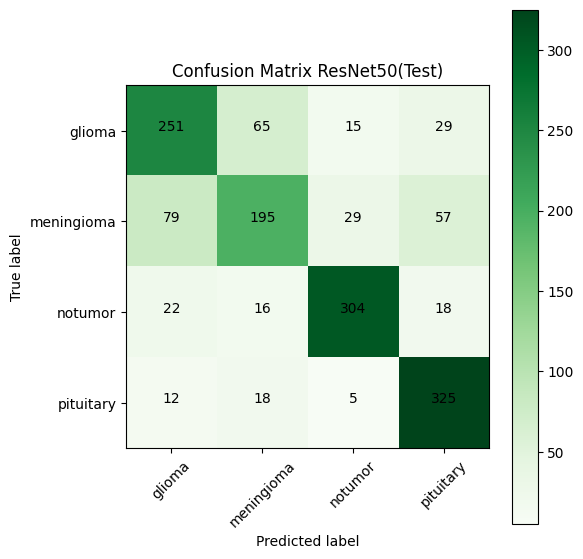


Classification Report:
              precision    recall  f1-score   support

      glioma       0.69      0.70      0.69       360
  meningioma       0.66      0.54      0.60       360
     notumor       0.86      0.84      0.85       360
   pituitary       0.76      0.90      0.82       360

    accuracy                           0.75      1440
   macro avg       0.74      0.75      0.74      1440
weighted avg       0.74      0.75      0.74      1440



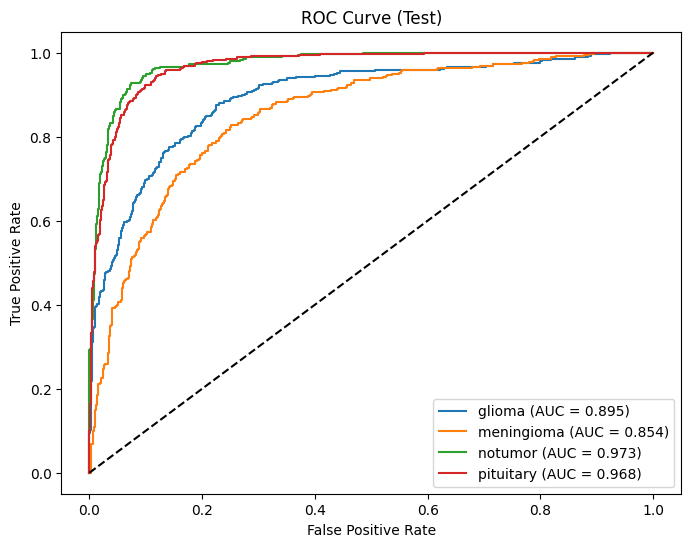

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import itertools

data_dir = "/mnt/data/split_70_10_20"

train_dir = os.path.join(data_dir, "Train")
val_dir   = os.path.join(data_dir, "Validation")
test_dir  = os.path.join(data_dir, "Test")

IMG_SIZE = (128,128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
normalizer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x,y: (normalizer(x),y))
val_ds   = val_ds.map(lambda x,y: (normalizer(x),y))
test_ds  = test_ds.map(lambda x,y: (normalizer(x),y))
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),  # Input image size
    include_top=False
)

base_model.trainable = False
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=15)

test_loss, test_acc = model.evaluate(test_ds)
print("\nTest Accuracy (ResNet50):", test_acc)

# Get predictions
y_true = np.concatenate([y for x,y in test_ds], axis=0)
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

# 4 Confusion Matrix with Green Color
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix with green color
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest', cmap='Greens')  # Green colormap
plt.title("Confusion Matrix ResNet50(Test)")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment="center")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))
y_true_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure(figsize=(8,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.show()

In [ ]:
model.save('ResNet50.h5')

In [ ]:
from google.colab import files
files.download('/content/ResNet50.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from tensorflow.keras.models import load_model
model_path = '/content/drive/MyDrive/Thesis 2026_MY/ED (Brain Tumor)/ResNet50.h5'
model = load_model(model_path)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Te-pi_39.jpg to Te-pi_39.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


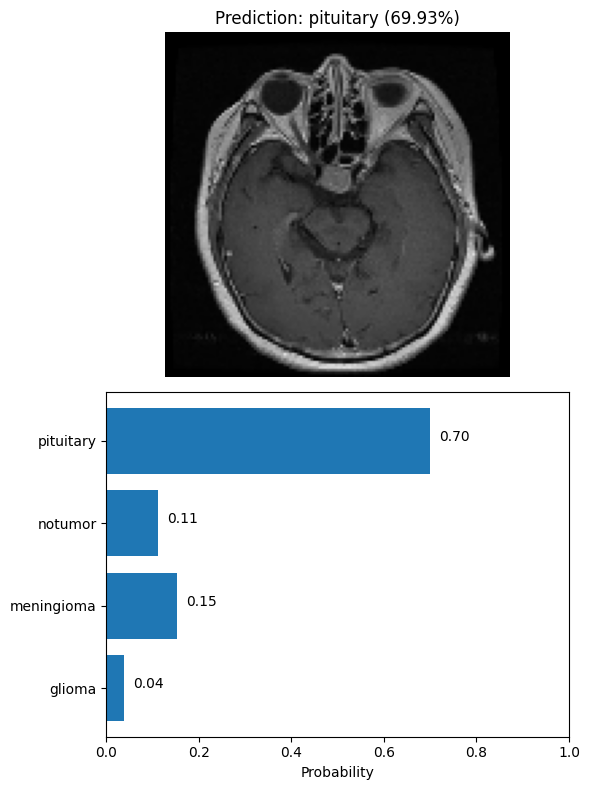

Predicted Class: pituitary
Confidence: 69.93 %


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]
IMG_SIZE = (128, 128)
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)
preds = model.predict(img_array)[0]
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
plt.figure(figsize=(6,8))
plt.subplot(2,1,1)
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {class_names[np.argmax(preds)]} ({np.max(preds)*100:.2f}%)")
plt.subplot(2,1,2)
bars = plt.barh(class_names, preds)
plt.xlim(0, 1)
plt.xlabel("Probability")
for i, v in enumerate(preds):
    plt.text(v + 0.02, i, f"{v:.2f}")
plt.tight_layout()
plt.show()
print("Predicted Class:", class_names[np.argmax(preds)])
print("Confidence:", round(np.max(preds)*100, 2), "%")

# **VGG16**

Found 5040 files belonging to 4 classes.
Found 720 files belonging to 4 classes.
Found 1440 files belonging to 4 classes.
Epoch 1/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 23s 121ms/step - accuracy: 0.5051 - loss: 1.1599 - val_accuracy: 0.7833 - val_loss: 0.6552
Epoch 2/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.7592 - loss: 0.6517 - val_accuracy: 0.8264 - val_loss: 0.5429
Epoch 3/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy: 0.7979 - loss: 0.5544 - val_accuracy: 0.8444 - val_loss: 0.4656
Epoch 4/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - accuracy: 0.8164 - loss: 0.4978 - val_accuracy: 0.8528 - val_loss: 0.4496
Epoch 5/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 0.8281 - loss: 0.4721 - val_accuracy: 0.8583 - val_loss: 0.4009
Epoch 6/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.8344 - loss: 0.4321 - val_accuracy: 0.8736 - val_loss: 0.3829
Epoch 7/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - accuracy: 0.8590 - loss: 0.4019 - val_acc

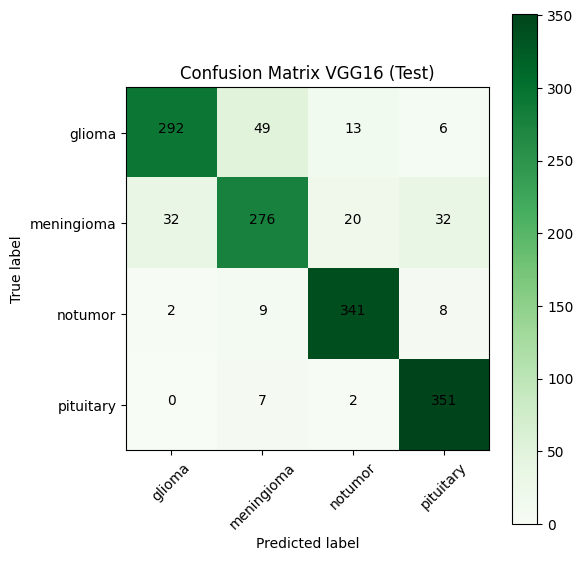


Classification Report(VGG16):
              precision    recall  f1-score   support

      glioma       0.90      0.81      0.85       360
  meningioma       0.81      0.77      0.79       360
     notumor       0.91      0.95      0.93       360
   pituitary       0.88      0.97      0.93       360

    accuracy                           0.88      1440
   macro avg       0.87      0.88      0.87      1440
weighted avg       0.87      0.88      0.87      1440



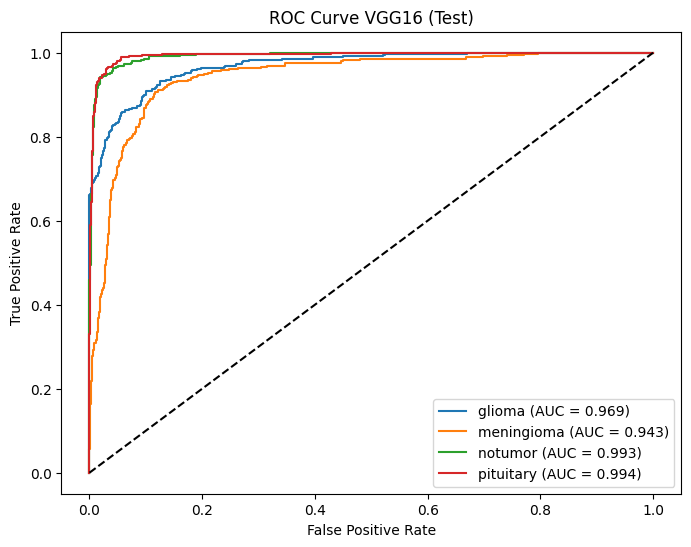

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import itertools

data_dir = "/mnt/data/split_70_10_20"

train_dir = os.path.join(data_dir, "Train")
val_dir   = os.path.join(data_dir, "Validation")
test_dir  = os.path.join(data_dir, "Test")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

# Normalize
normalizer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalizer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalizer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalizer(x), y))

#  VGG16 with Transfer Learning
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False
)

base_model.trainable = False
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=15)
test_loss, test_acc = model.evaluate(test_ds)
print("\nTest Accuracy (VGG16):", test_acc)

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest', cmap='Greens')  # Green colormap
plt.title("Confusion Matrix VGG16 (Test)")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment="center")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

#  Classification Report
print("\nClassification Report(VGG16):")
print(classification_report(y_true, y_pred, target_names=class_names))

#  ROC Curve & AUC
y_true_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure(figsize=(8,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve VGG16 (Test)")
plt.legend()
plt.show()

# **Inception-V3**

Found 5040 files belonging to 4 classes.
Found 720 files belonging to 4 classes.
Found 1440 files belonging to 4 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 41s 160ms/step - accuracy: 0.5808 - loss: 1.4614 - val_accuracy: 0.8014 - val_loss: 0.5343
Epoch 2/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.7549 - loss: 0.6164 - val_accuracy: 0.8278 - val_loss: 0.4641
Epoch 3/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.7845 - loss: 0.5444 - val_accuracy: 0.8472 - val_loss: 0.4302
Epoch 4/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8114 - loss: 0.4861 - val_accuracy: 0.8528 - val_loss: 0.4043
Epoch 5/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.8332 - loss: 0.4536 - val_accuracy: 0.8597 - val_loss: 0.3862
Epoch 6/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8349 - loss: 0.4251 - val_accuracy: 0.8625 - val_loss: 0.3728
Epoch 7/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/ste

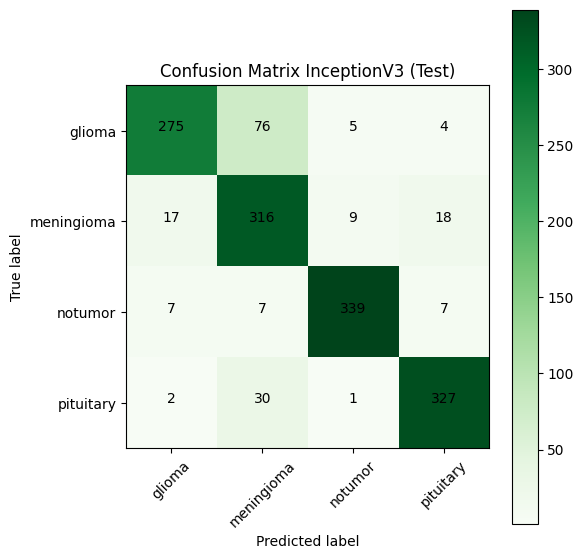


Classification Report:
              precision    recall  f1-score   support

      glioma       0.91      0.76      0.83       360
  meningioma       0.74      0.88      0.80       360
     notumor       0.96      0.94      0.95       360
   pituitary       0.92      0.91      0.91       360

    accuracy                           0.87      1440
   macro avg       0.88      0.87      0.87      1440
weighted avg       0.88      0.87      0.87      1440



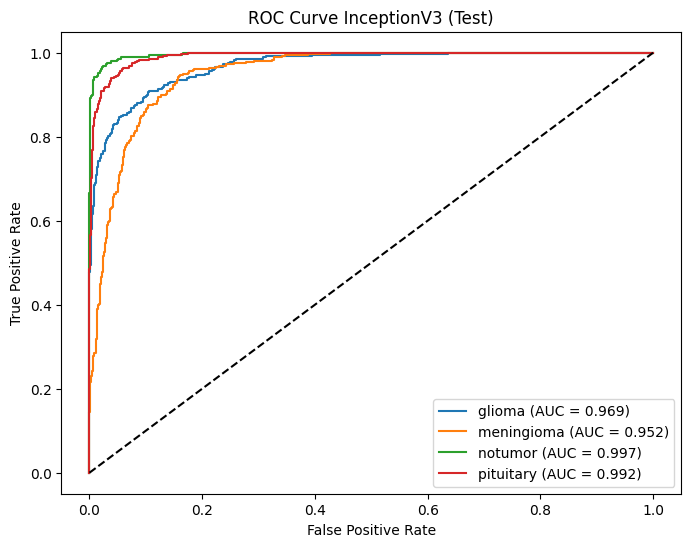

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import itertools
data_dir = "/mnt/data/split_70_10_20"

train_dir = os.path.join(data_dir, "Train")
val_dir   = os.path.join(data_dir, "Validation")
test_dir  = os.path.join(data_dir, "Test")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
normalizer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalizer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalizer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalizer(x), y))

# InceptionV3 with Transfer Learning
base_model = tf.keras.applications.InceptionV3(
    weights='imagenet',
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False
)
base_model.trainable = False

# Add new layers for classification
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=15)

# Evaluation
test_loss, test_acc = model.evaluate(test_ds)
print("\nTest Accuracy (InceptionV3):", test_acc)

# Get predictions
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

# Confusion Matrix with Green Color
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix with green color
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest', cmap='Greens')  # Green colormap
plt.title("Confusion Matrix InceptionV3 (Test)")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             horizontalalignment="center")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ROC Curve & AUC
y_true_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure(figsize=(8,6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve InceptionV3 (Test)")
plt.legend()
plt.show()

# **Our NeuroStackNet: Hybrid Stacking Ensemble for Multi-Class Brain Tumour Classification**

**Base Learners (InceptionV3 & CNN) + Meta-Learner Training, Evaluation, and Visualization**

Found 5040 files belonging to 4 classes.
Found 720 files belonging to 4 classes.
Found 1440 files belonging to 4 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 47s 179ms/step - accuracy: 0.5463 - loss: 1.4808 - val_accuracy: 0.8153 - val_loss: 0.5432
Epoch 2/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.7514 - loss: 0.6229 - val_accuracy: 0.8222 - val_loss: 0.4565
Epoch 3/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.7821 - loss: 0.5506 - val_accuracy: 0.8528 - val_loss: 0.4476
Epoch 4/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.8000 - loss: 0.4992 - val_accuracy: 0.8583 - val_loss: 0.4193
Epoch 5/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.8171 - loss: 0.4649 - val_accuracy: 0.8278 - val_loss: 0.4195
Epoch 6/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.8204 - loss: 0.4571 - val_accuracy: 0.8514 - val_loss: 0.3925
Epoch 7/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


158/158 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - accuracy: 0.5627 - loss: 1.0211 - val_accuracy: 0.7611 - val_loss: 0.5713
Epoch 2/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.7975 - loss: 0.5411 - val_accuracy: 0.8292 - val_loss: 0.4270
Epoch 3/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.8371 - loss: 0.4184 - val_accuracy: 0.8444 - val_loss: 0.3997
Epoch 4/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.8806 - loss: 0.3243 - val_accuracy: 0.8972 - val_loss: 0.2745
Epoch 5/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9118 - loss: 0.2431 - val_accuracy: 0.9153 - val_loss: 0.2435
Epoch 6/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9233 - loss: 0.1947 - val_accuracy: 0.8819 - val_loss: 0.2833
Epoch 7/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9411 - loss: 0.1507 - val_accuracy: 0.9375 - val_loss: 0.2063
Epoch 8/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.9531 - loss: 0.1222 - val_accuracy: 0.92

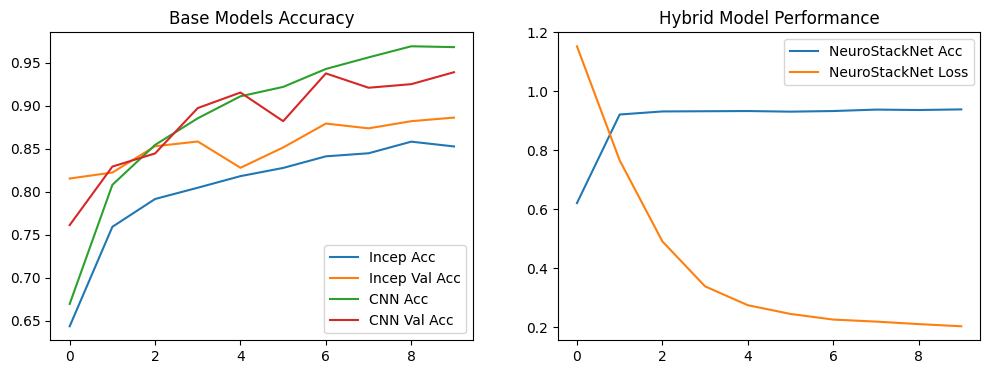

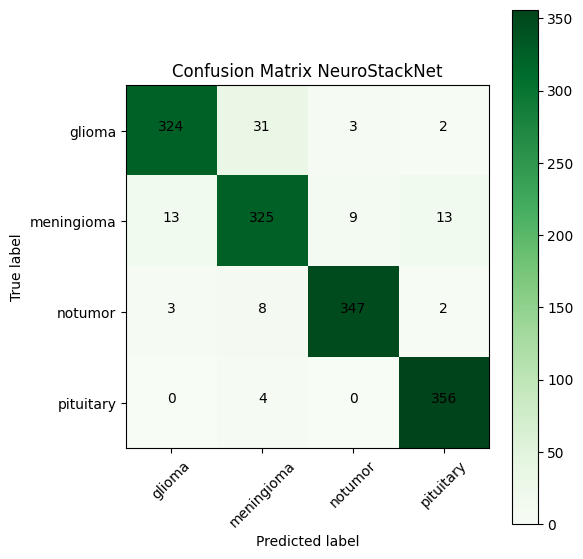


Classification Report (NeuroStackNet):
              precision    recall  f1-score   support

      glioma       0.95      0.90      0.93       360
  meningioma       0.88      0.90      0.89       360
     notumor       0.97      0.96      0.97       360
   pituitary       0.95      0.99      0.97       360

    accuracy                           0.94      1440
   macro avg       0.94      0.94      0.94      1440
weighted avg       0.94      0.94      0.94      1440



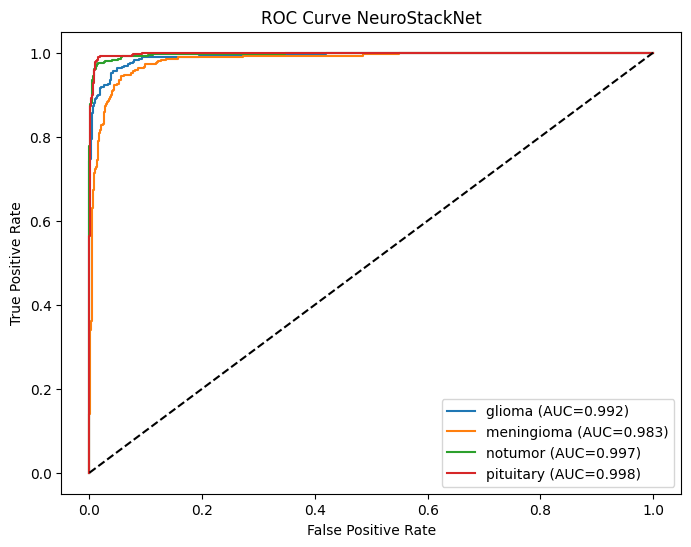

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import itertools

# Load Dataset
data_dir = "/mnt/data/split_70_10_20"
train_dir = os.path.join(data_dir, "Train")
val_dir   = os.path.join(data_dir, "Validation")
test_dir  = os.path.join(data_dir, "Test")

IMG_SIZE = (128,128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED)
val_ds   = tf.keras.utils.image_dataset_from_directory(val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED)
test_ds  = tf.keras.utils.image_dataset_from_directory(test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_ds.class_names
num_classes = len(class_names)

normalizer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalizer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalizer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalizer(x), y))

# Base Model 1: InceptionV3
base_incep = tf.keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0],IMG_SIZE[1],3))
base_incep.trainable = False

model_incep = keras.Sequential([
    base_incep,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model_incep.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_incep = model_incep.fit(train_ds, validation_data=val_ds, epochs=10)

# Base Model 2: Custom CNN
model_cnn = keras.Sequential([
    layers.Conv2D(32,3,activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes,activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_cnn = model_cnn.fit(train_ds, validation_data=val_ds, epochs=10)

# Stacking Predictions
y_true = np.concatenate([y for x,y in test_ds], axis=0)

y_prob_incep = model_incep.predict(test_ds)
y_prob_cnn   = model_cnn.predict(test_ds)

X_meta = np.hstack([y_prob_incep, y_prob_cnn])

# Meta Model: NeuroStackNet
meta_input = keras.Input(shape=(X_meta.shape[1],))
x = layers.Dense(64, activation='relu')(meta_input)
x = layers.Dropout(0.3)(x)
meta_output = layers.Dense(num_classes, activation='softmax')(x)

meta_model = keras.Model(inputs=meta_input, outputs=meta_output)
meta_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_meta = meta_model.fit(X_meta, y_true, epochs=10, batch_size=32)

# Evaluation
y_pred_prob = meta_model.predict(X_meta)
y_pred = np.argmax(y_pred_prob, axis=1)

test_acc = np.mean(y_pred == y_true)
print("\nTest Accuracy (NeuroStackNet):", test_acc)

# Accuracy & Loss Curves
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_incep.history['accuracy'], label='Incep Acc')
plt.plot(history_incep.history['val_accuracy'], label='Incep Val Acc')
plt.plot(history_cnn.history['accuracy'], label='CNN Acc')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val Acc')
plt.title('Base Models Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_meta.history['accuracy'], label='NeuroStackNet Acc')
plt.plot(history_meta.history['loss'], label='NeuroStackNet Loss')
plt.title('Hybrid Model Performance')
plt.legend()

plt.show()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest', cmap='Greens')
plt.title("Confusion Matrix NeuroStackNet")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j,i,cm[i,j],horizontalalignment='center')

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report (NeuroStackNet):")
print(classification_report(y_true, y_pred, target_names=class_names))

# ROC Curve
y_true_bin = label_binarize(y_true, classes=range(num_classes))
plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_pred_prob[:,i])
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f"{class_names[i]} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve NeuroStackNet")
plt.legend()
plt.show()

In [ ]:
import os
os.listdir()

['.config', 'Te-no_1 (1).jpg', 'Te-no_1.jpg', 'drive', 'sample_data']

# **Save Model**

In [ ]:
model.save('NeuroStackNet_Model.h5')

In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/Thesis 2026_MY/ED (Brain Tumor)/Model/NeuroStackNet_Model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from tensorflow.keras.models import load_model
model_path = '/content/drive/MyDrive/Thesis 2026_MY/ED (Brain Tumor)/Model/NeuroStackNet_Model.h5'
model = load_model(model_path)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Te-no_1.jpg to Te-no_1 (1).jpg


# **Predicting Brain Tumour Class for Uploaded MRI Images**

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


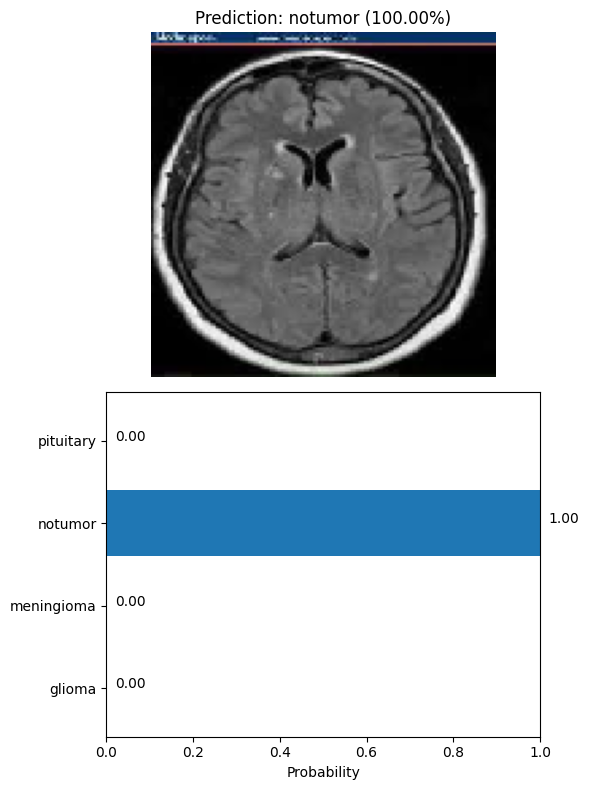

Model Name: NeuroStackNet
Predicted Class: notumor
Confidence: 100.0 %


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]
IMG_SIZE = (128, 128)
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)
preds = model.predict(img_array)[0]
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
plt.figure(figsize=(6,8))
plt.subplot(2,1,1)
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {class_names[np.argmax(preds)]} ({np.max(preds)*100:.2f}%)")
plt.subplot(2,1,2)
bars = plt.barh(class_names, preds)
plt.xlim(0, 1)
plt.xlabel("Probability")
for i, v in enumerate(preds):
    plt.text(v + 0.02, i, f"{v:.2f}")
plt.tight_layout()
plt.show()
print("Model Name: NeuroStackNet")
print("Predicted Class:", class_names[np.argmax(preds)])
print("Confidence:", round(np.max(preds)*100, 2), "%")